### 3.3. Standardisierte Hyperparameter-Optimierung

In dieser Optimierungsrunde haben wir für alle Modelle gezielt Hyperparameter optimiert. Dabei wurden Parameter wie Baumanzahl, Tiefe, Lernrate und Regularisierung angepasst.

In der dritten Optimierungsrunde optimiere ich alle Modelle systematisch über ihre wichtigsten Parameter, um faire und vergleichbare Ergebnisse zu erzielen. Für jedes Modell wurden sinnvolle Wertebereiche definiert (z. B. Anzahl Bäume, Baumtiefe, Lernrate) und im Rahmen einer zufälligen Parameterauswahl getestet. Hierfür wurde eine eigene Implementierung eines Randomized Search verwendet, die es ermöglicht, gezielt unsere projektspezifische wirtschaftliche Zielfunktion als Bewertungsmaßstab zu verwenden. Diese Zielfunktion berücksichtigt die Kosten von Fehlern direkt, indem sie den Schaden durch False Negatives sowie Kosten für False Positives und Einsparungen durch True Positives abbildet. Ziel ist es, die vielversprechendsten Modelle für die abschließende Feinoptimierung auszuwählen.

Die Hyperparameteroptimierung selbst wurde bewusst ohne parallele Verarbeitung der Suchschleifen ausgeführt, um Stabilitätsprobleme (z. B. beim Pickling von Pipelines) zu vermeiden. Die interne Parallelisierung der Modelle wurde hingegen bei allen unterstützenden Algorithmen über n_jobs=4 aktiviert, um die Mehrkern-Architektur des eingesetzten Rechners effizient auszunutzen.

In [1]:
# Standard Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import logging

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay, 
    roc_auc_score, RocCurveDisplay, precision_recall_curve, PrecisionRecallDisplay
)
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier

# neue Modelle (nach pip install)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from imblearn.ensemble import BalancedRandomForestClassifier, RUSBoostClassifier

# Logging & Warnings Setup
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
warnings.filterwarnings("ignore")

In [2]:
# Preprocessor laden
from pipeline.data_pipeline import preprocessor, X, y

## 1. Datenaufteilung

In [3]:

# damage extrahieren und aus X entfernen
damage_series = X['damage'].copy()
X = X.drop(columns=['damage'])

# stratify=y sorgt für eine proportionale Aufteilung der Klassen in Train/Test, wichtig bei unbalancierten Datensets.
if isinstance(y, pd.Series) and y.nunique() > 1 and y.notnull().all():
    stratify_param = y
else:
    stratify_param = None

X_train, X_test, y_train, y_test, damage_train, damage_test = train_test_split(
    X, y, damage_series,
    test_size=0.2,
    random_state=42,
    stratify=stratify_param
)


## 2. Zielfunktion definieren

In [4]:
def custom_objective_score(y_true, y_pred, damage_series):
    """
    Custom Zielfunktion:
    Score = -Summe Schaden der FN + (5 * TP) - (10 * FP)
    """
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()
    
    fn_mask = (y_true == 1) & (y_pred == 0)
    sum_damage_fn = damage_series[fn_mask].sum()
    
    score = -sum_damage_fn + (5 * TP) - (10 * FP)
    return float(score)

## 3. Evaluationsfunktion definieren

In [5]:
def evaluate_model_with_curves(model, model_name, preprocessor, X_train, X_test, y_train, y_test, damage_test, threshold):
    logging.info(f"🔍 Starte Evaluation für Modell: {model_name}")

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    if y_train.isnull().any():
        logging.warning(f"y_train enthält NaN-Werte: {y_train.isnull().sum()} fehlende Werte!")
        return

    try:
        pipeline.fit(X_train, y_train)
    except Exception as e:
        logging.exception(f"Fehler beim Training: {e}")
        return

    has_proba = hasattr(model, "predict_proba")
    if has_proba:
        y_scores = pipeline.predict_proba(X_test)[:, 1]
        y_pred = (y_scores >= threshold).astype(int)
    else:
        logging.warning("⚠️ Modell unterstützt kein predict_proba.")
        y_scores = None
        y_pred = pipeline.predict(X_test)

    # Klassifikationsbericht
    print("\n📋 Klassifikationsbericht:")
    print(classification_report(y_test, y_pred, target_names=["NORMAL", "FRAUD"]))

    # Konfusionsmatrix
    cm = confusion_matrix(y_test, y_pred)
    print("\n🔲 Konfusionsmatrix:")
    print(cm)
    ConfusionMatrixDisplay(cm, display_labels=["NORMAL", "FRAUD"]).plot(cmap="Blues")
    plt.title(f"Konfusionsmatrix – {model_name} (Threshold: {threshold:.2f})")
    plt.show()

    # ROC & PR-Kurven
    if has_proba and y_scores is not None:
        auc = roc_auc_score(y_test, y_scores)
        logging.info(f"📈 ROC-AUC: {auc:.4f}")
        RocCurveDisplay.from_predictions(y_test, y_scores).plot()
        plt.plot([0, 1], [0, 1], 'k--', label='Zufall')
        plt.legend()
        plt.title(f"ROC-Kurve – {model_name}")
        plt.show()

        precision, recall, _ = precision_recall_curve(y_test, y_scores)
        PrecisionRecallDisplay(precision=precision, recall=recall).plot()
        plt.title(f"Precision-Recall-Kurve – {model_name}")
        plt.show()

    if len(y_test) != len(damage_test):
        logging.error("Länge von y_test und damage_test stimmen nicht überein!")
        return

    custom_score = custom_objective_score(y_test.reset_index(drop=True), y_pred, damage_test.reset_index(drop=True))
    print(f"\n🎯 Wert der Zielfunktion: {custom_score:.2f}")

    return custom_score  # Optionaler Rückgabewert

## 4. Randomized Search mit Custom Scoring

In [6]:
def randomized_search_with_custom_score(model_class, param_grid, preprocessor, 
                                        X, y, damage_series, 
                                        model_fixed_params=None, 
                                        n_iter=10, cv_splits=5, random_state=42):
    """
    Randomisierte Hyperparameter-Suche mit Custom Objective Function und optionalen festen Modellparametern.
    """
    rng = np.random.default_rng(seed=random_state)
    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    best_score = -np.inf
    best_params = None
    param_grid_items = list(param_grid.items())

    for iteration in range(n_iter):
        params = {key: rng.choice(list(values)) for key, values in param_grid_items}
        full_params = {**params}
        if model_fixed_params:
            full_params.update(model_fixed_params)

        logging.info(f"\n➡️ Iteration {iteration+1}: teste Parameter {full_params}")
        fold_scores = []

        for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):
            X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
            y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
            damage_valid = damage_series.iloc[valid_idx]

            pipeline = Pipeline([
                ('preprocessor', preprocessor),
                ('classifier', model_class(**full_params))
            ])

            try:
                pipeline.fit(X_train, y_train)
                y_pred = pipeline.predict(X_valid)
                score = custom_objective_score(
                    y_valid.reset_index(drop=True),
                    y_pred,
                    damage_valid.reset_index(drop=True)
                )
                fold_scores.append(score)
                logging.info(f"  Fold {fold} Score: {score:.2f}")
            except Exception as e:
                logging.error(f"❌ Fehler in Fold {fold}: {e}")
                continue

        if not fold_scores:
            logging.warning(f"⚠️ Keine gültigen Folds in Iteration {iteration+1}.")
            continue

        mean_score = np.mean(fold_scores)
        logging.info(f"  ➡️ Durchschnittlicher CV-Score: {mean_score:.2f}")

        if mean_score > best_score:
            best_score = mean_score
            best_params = full_params

    logging.info("\n✅ Beste Parameter gefunden!")
    logging.info(f"✅ Parameter: {best_params}")
    logging.info(f"✅ CV-Score: {best_score:.2f}")
    return best_params, best_score

## 6. Master-Liste mit allen Modellen und Parametern:

In [7]:
model_configs = [
    {
        'name': 'LogisticRegression',
        'model_class': LogisticRegression,
        'param_grid': {
            'C': [0.01, 0.1, 1, 10, 100],
            'solver': ['liblinear', 'lbfgs'],
            'max_iter': [1000]
        },
        'fixed_params': {}
    },
    {
        'name': 'RandomForestClassifier',
        'model_class': RandomForestClassifier,
        'param_grid': {
            'n_estimators': [100, 300, 500],
            'max_depth': [5, 10, 20, None],
            'min_samples_split': [2, 5, 10]
        },
        'fixed_params': {'n_jobs': 4}
    },
    {
        'name': 'GradientBoostingClassifier',
        'model_class': GradientBoostingClassifier,
        'param_grid': {
            'n_estimators': [100, 300, 500],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 7],
            'subsample': [0.7, 0.8, 1.0]
        },
        'fixed_params': {}
    },
    {
        'name': 'HistGradientBoostingClassifier',
        'model_class': HistGradientBoostingClassifier,
        'param_grid': {
            'max_iter': [100, 300, 500],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [None, 10, 20]
        },
        'fixed_params': {}
    },
    {
        'name': 'XGBClassifier',
        'model_class': XGBClassifier,
        'param_grid': {
            'n_estimators': [100, 300, 500],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 7],
            'subsample': [0.7, 0.8, 1.0],
            'colsample_bytree': [0.7, 0.8, 1.0]
        },
        'fixed_params': {'use_label_encoder': False, 'eval_metric': 'logloss', 'n_jobs': 4}
    },
    {
        'name': 'CatBoostClassifier',
        'model_class': CatBoostClassifier,
        'param_grid': {
            'iterations': [100, 300, 500],
            'learning_rate': [0.01, 0.05, 0.1],
            'depth': [4, 6, 8]
        },
        'fixed_params': {'verbose': 0}
    },
    {
        'name': 'BalancedRandomForestClassifier',
        'model_class': BalancedRandomForestClassifier,
        'param_grid': {
            'n_estimators': [100, 300, 500],
            'max_depth': [5, 10, None]
        },
        'fixed_params': {'n_jobs': 4}
    },
    {
        'name': 'RUSBoostClassifier',
        'model_class': RUSBoostClassifier,
        'param_grid': {
            'n_estimators': [50, 100, 300],
            'learning_rate': [0.01, 0.05, 0.1]
        },
        'fixed_params': {'estimator': DecisionTreeClassifier(max_depth=3), 'random_state': 42}
    },
    {
        'name': 'LGBMClassifier',
        'model_class': LGBMClassifier,
        'param_grid': {
            'n_estimators': [100, 300, 500],
            'learning_rate': [0.01, 0.05, 0.1],
            'num_leaves': [20, 31, 50],
            'max_depth': [5, 10, 20]
        },
        'fixed_params': {'n_jobs': 4}
    }
] 

## 7. Ausgabe aller Ergebnisse

2025-06-08 18:15:25,491 - INFO - 
➡️ Iteration 1: teste Parameter {'C': 0.01, 'solver': 'lbfgs', 'max_iter': 1000}




🔍 Tune: LogisticRegression


2025-06-08 18:15:40,425 - INFO -   Fold 1 Score: -6272.90
2025-06-08 18:15:46,103 - INFO -   Fold 2 Score: -6401.57
2025-06-08 18:15:52,295 - INFO -   Fold 3 Score: -6438.78
2025-06-08 18:16:00,945 - INFO -   Fold 4 Score: -5863.19
2025-06-08 18:16:05,981 - INFO -   Fold 5 Score: -6439.45
2025-06-08 18:16:05,981 - INFO -   ➡️ Durchschnittlicher CV-Score: -6283.18
2025-06-08 18:16:05,981 - INFO - 
➡️ Iteration 2: teste Parameter {'C': 10.0, 'solver': 'liblinear', 'max_iter': 1000}
2025-06-08 18:16:13,223 - INFO -   Fold 1 Score: -6115.07
2025-06-08 18:16:20,082 - INFO -   Fold 2 Score: -6276.28
2025-06-08 18:16:27,565 - INFO -   Fold 3 Score: -6245.61
2025-06-08 18:16:38,285 - INFO -   Fold 4 Score: -5727.94
2025-06-08 18:16:49,592 - INFO -   Fold 5 Score: -6383.17
2025-06-08 18:16:49,594 - INFO -   ➡️ Durchschnittlicher CV-Score: -6149.61
2025-06-08 18:16:49,595 - INFO - 
➡️ Iteration 3: teste Parameter {'C': 1.0, 'solver': 'lbfgs', 'max_iter': 1000}
2025-06-08 18:16:54,235 - INFO -   


📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.98     30139
       FRAUD       1.00      0.01      0.03      1000

    accuracy                           0.97     31139
   macro avg       0.98      0.51      0.51     31139
weighted avg       0.97      0.97      0.95     31139


🔲 Konfusionsmatrix:
[[30139     0]
 [  986    14]]


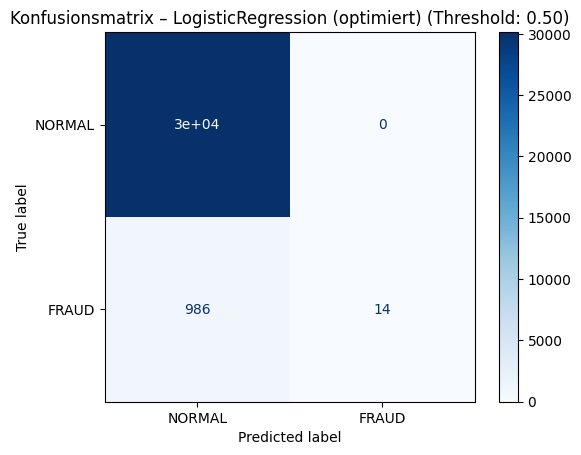

2025-06-08 18:21:30,113 - INFO - 📈 ROC-AUC: 0.8192


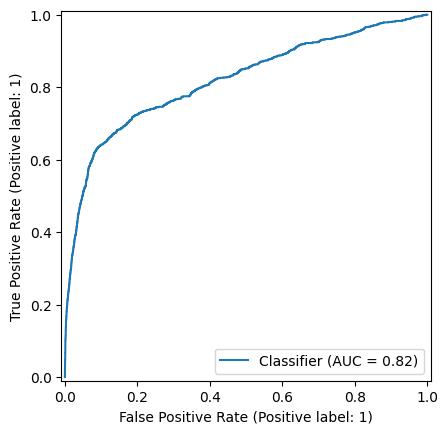

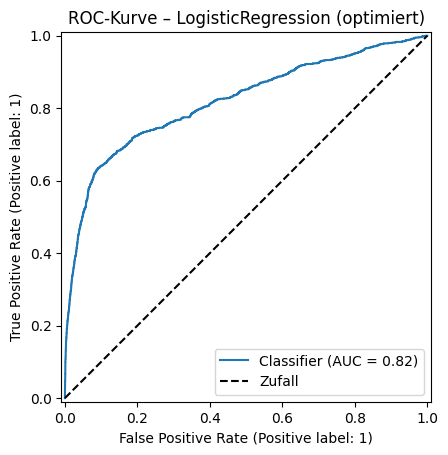

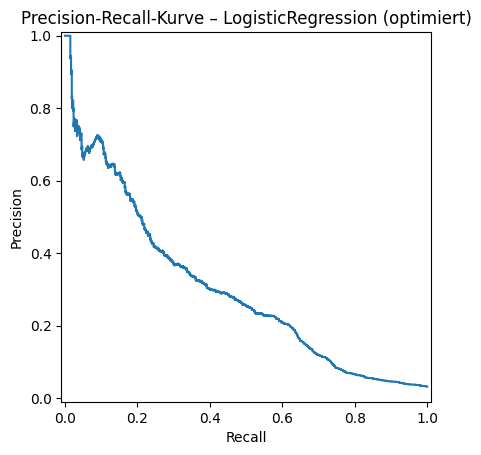

2025-06-08 18:21:30,484 - INFO - 
➡️ Iteration 1: teste Parameter {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 5, 'n_jobs': 4}



🎯 Wert der Zielfunktion: -7644.34


🔍 Tune: RandomForestClassifier


2025-06-08 18:21:45,163 - INFO -   Fold 1 Score: -5218.57
2025-06-08 18:21:58,480 - INFO -   Fold 2 Score: -4884.71
2025-06-08 18:22:09,630 - INFO -   Fold 3 Score: -4903.60
2025-06-08 18:22:20,494 - INFO -   Fold 4 Score: -4713.14
2025-06-08 18:22:32,905 - INFO -   Fold 5 Score: -5113.19
2025-06-08 18:22:32,910 - INFO -   ➡️ Durchschnittlicher CV-Score: -4966.64
2025-06-08 18:22:32,910 - INFO - 
➡️ Iteration 2: teste Parameter {'n_estimators': 300, 'max_depth': 10, 'min_samples_split': 10, 'n_jobs': 4}
2025-06-08 18:22:54,297 - INFO -   Fold 1 Score: -5166.76
2025-06-08 18:23:12,472 - INFO -   Fold 2 Score: -5044.01
2025-06-08 18:23:31,568 - INFO -   Fold 3 Score: -5063.28
2025-06-08 18:23:53,804 - INFO -   Fold 4 Score: -4723.82
2025-06-08 18:24:18,867 - INFO -   Fold 5 Score: -5040.73
2025-06-08 18:24:18,868 - INFO -   ➡️ Durchschnittlicher CV-Score: -5007.72
2025-06-08 18:24:18,868 - INFO - 
➡️ Iteration 3: teste Parameter {'n_estimators': 100, 'max_depth': 20, 'min_samples_split':


📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.99     30139
       FRAUD       0.71      0.17      0.27      1000

    accuracy                           0.97     31139
   macro avg       0.84      0.58      0.63     31139
weighted avg       0.96      0.97      0.96     31139


🔲 Konfusionsmatrix:
[[30069    70]
 [  831   169]]


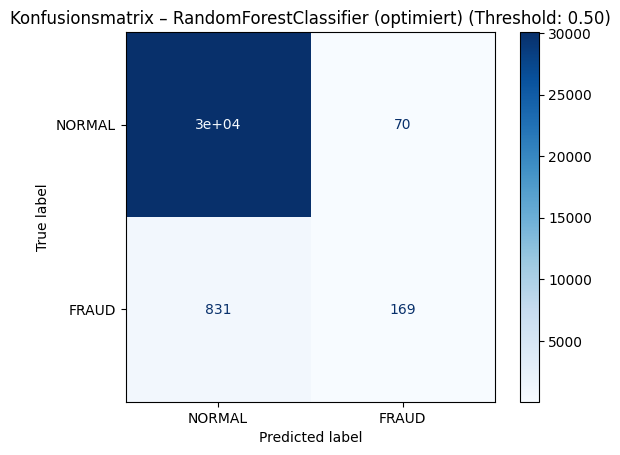

2025-06-08 18:46:08,448 - INFO - 📈 ROC-AUC: 0.8218


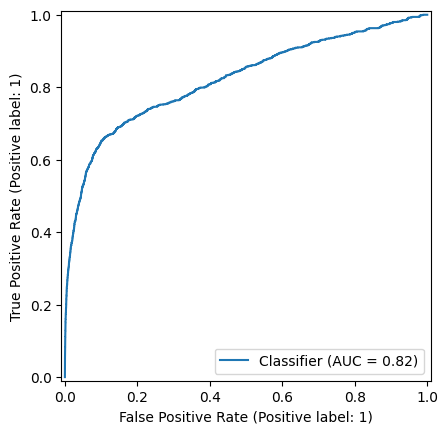

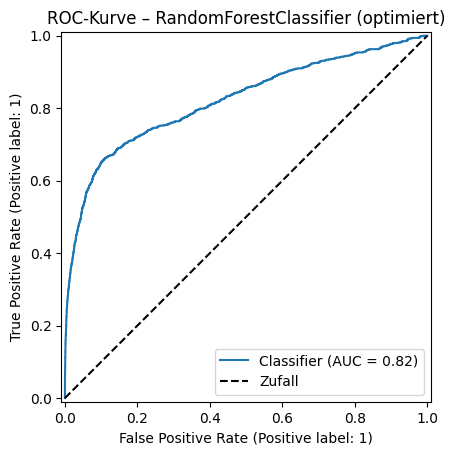

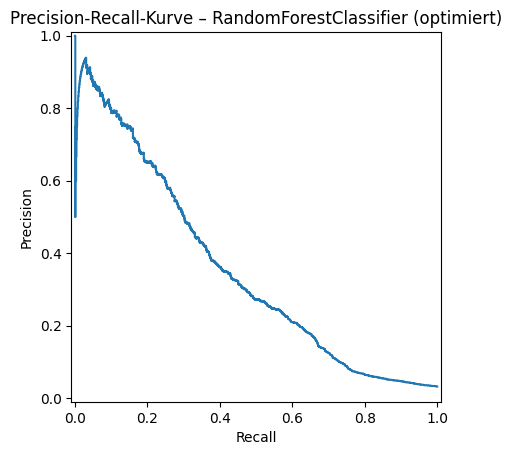

2025-06-08 18:46:09,051 - INFO - 
➡️ Iteration 1: teste Parameter {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 5, 'subsample': 0.8}



🎯 Wert der Zielfunktion: -6112.89


🔍 Tune: GradientBoostingClassifier


2025-06-08 18:47:13,408 - INFO -   Fold 1 Score: -5512.10
2025-06-08 18:48:17,052 - INFO -   Fold 2 Score: -5350.99
2025-06-08 18:49:20,397 - INFO -   Fold 3 Score: -5128.81
2025-06-08 18:50:23,094 - INFO -   Fold 4 Score: -5160.47
2025-06-08 18:51:27,084 - INFO -   Fold 5 Score: -5197.07
2025-06-08 18:51:27,084 - INFO -   ➡️ Durchschnittlicher CV-Score: -5269.89
2025-06-08 18:51:27,084 - INFO - 
➡️ Iteration 2: teste Parameter {'n_estimators': 300, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 1.0}
2025-06-08 18:53:45,289 - INFO -   Fold 1 Score: -5283.10
2025-06-08 18:56:06,231 - INFO -   Fold 2 Score: -5069.57
2025-06-08 18:58:26,033 - INFO -   Fold 3 Score: -4991.95
2025-06-08 19:00:44,467 - INFO -   Fold 4 Score: -4882.59
2025-06-08 19:03:04,651 - INFO -   Fold 5 Score: -5004.91
2025-06-08 19:03:04,651 - INFO -   ➡️ Durchschnittlicher CV-Score: -5046.42
2025-06-08 19:03:04,651 - INFO - 
➡️ Iteration 3: teste Parameter {'n_estimators': 100, 'learning_rate': 0.01, 'max_depth': 


📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.99     30139
       FRAUD       0.71      0.18      0.29      1000

    accuracy                           0.97     31139
   macro avg       0.84      0.59      0.64     31139
weighted avg       0.96      0.97      0.96     31139


🔲 Konfusionsmatrix:
[[30064    75]
 [  820   180]]


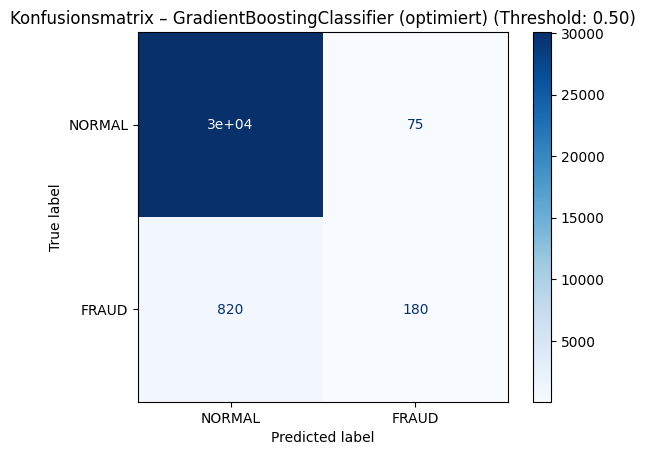

2025-06-08 21:16:35,929 - INFO - 📈 ROC-AUC: 0.8414


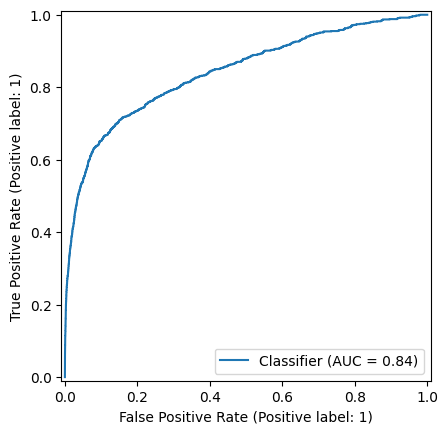

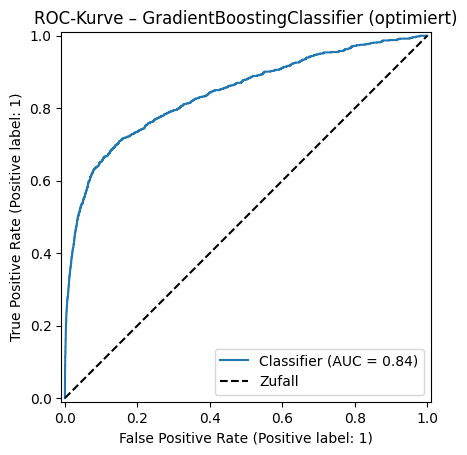

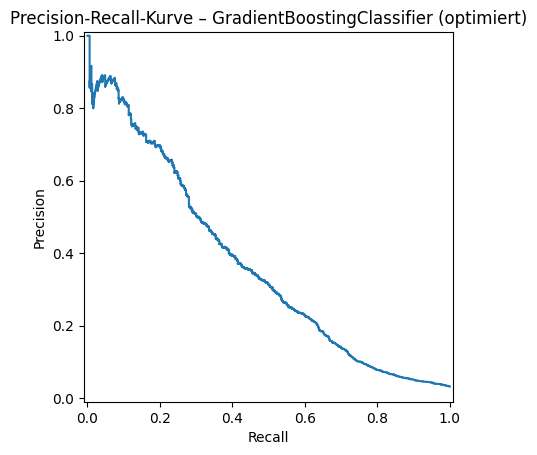

2025-06-08 21:16:36,323 - INFO - 
➡️ Iteration 1: teste Parameter {'max_iter': 100, 'learning_rate': 0.1, 'max_depth': 10}



🎯 Wert der Zielfunktion: -5978.93


🔍 Tune: HistGradientBoostingClassifier


2025-06-08 21:16:44,974 - INFO -   Fold 1 Score: -5351.56
2025-06-08 21:16:49,588 - INFO -   Fold 2 Score: -5098.74
2025-06-08 21:16:55,953 - INFO -   Fold 3 Score: -5026.33
2025-06-08 21:17:01,582 - INFO -   Fold 4 Score: -4865.11
2025-06-08 21:17:06,496 - INFO -   Fold 5 Score: -5094.32
2025-06-08 21:17:06,498 - INFO -   ➡️ Durchschnittlicher CV-Score: -5087.21
2025-06-08 21:17:06,498 - INFO - 
➡️ Iteration 2: teste Parameter {'max_iter': 300, 'learning_rate': 0.05, 'max_depth': 20}
2025-06-08 21:17:13,092 - INFO -   Fold 1 Score: -5292.96
2025-06-08 21:17:18,910 - INFO -   Fold 2 Score: -5008.72
2025-06-08 21:17:24,278 - INFO -   Fold 3 Score: -4880.60
2025-06-08 21:17:29,846 - INFO -   Fold 4 Score: -4692.45
2025-06-08 21:17:35,212 - INFO -   Fold 5 Score: -5033.70
2025-06-08 21:17:35,212 - INFO -   ➡️ Durchschnittlicher CV-Score: -4981.69
2025-06-08 21:17:35,217 - INFO - 
➡️ Iteration 3: teste Parameter {'max_iter': 100, 'learning_rate': 0.1, 'max_depth': None}
2025-06-08 21:17:39


📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.99     30139
       FRAUD       0.72      0.16      0.26      1000

    accuracy                           0.97     31139
   macro avg       0.85      0.58      0.62     31139
weighted avg       0.96      0.97      0.96     31139


🔲 Konfusionsmatrix:
[[30077    62]
 [  840   160]]


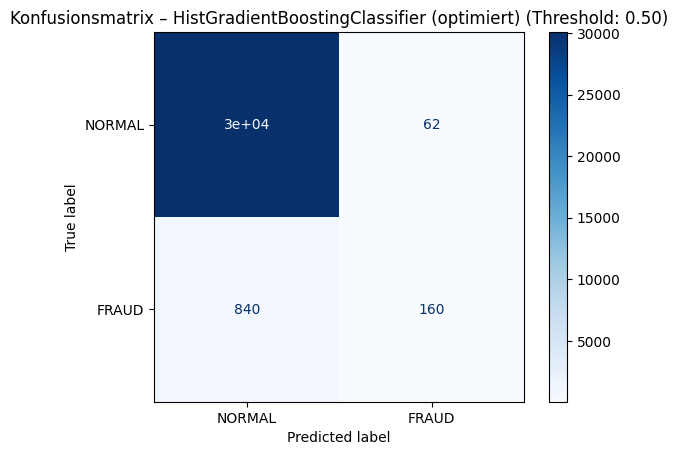

2025-06-08 21:21:36,009 - INFO - 📈 ROC-AUC: 0.8361


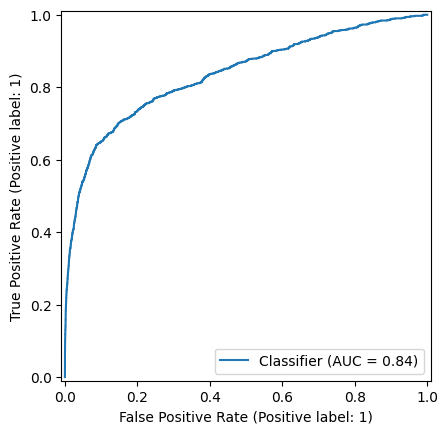

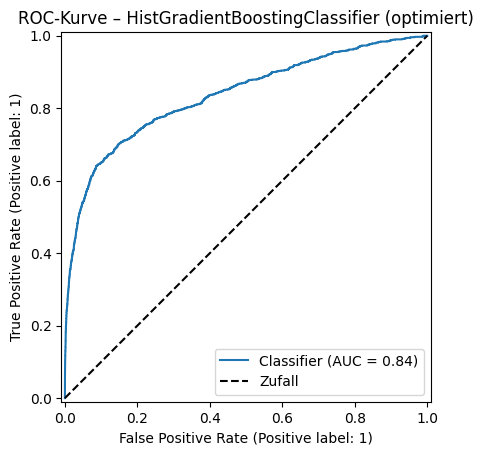

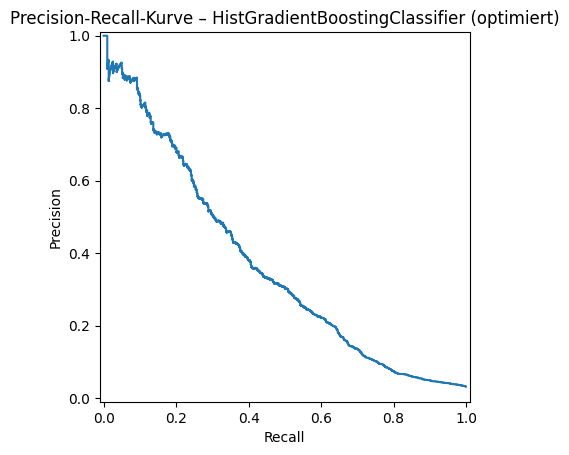

2025-06-08 21:21:36,423 - INFO - 
➡️ Iteration 1: teste Parameter {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'use_label_encoder': False, 'eval_metric': 'logloss', 'n_jobs': 4}



🎯 Wert der Zielfunktion: -6149.00


🔍 Tune: XGBClassifier


2025-06-08 21:21:41,571 - INFO -   Fold 1 Score: -5265.07
2025-06-08 21:21:47,042 - INFO -   Fold 2 Score: -4869.69
2025-06-08 21:21:52,246 - INFO -   Fold 3 Score: -4980.51
2025-06-08 21:21:57,426 - INFO -   Fold 4 Score: -4635.67
2025-06-08 21:22:02,461 - INFO -   Fold 5 Score: -4971.91
2025-06-08 21:22:02,461 - INFO -   ➡️ Durchschnittlicher CV-Score: -4944.57
2025-06-08 21:22:02,461 - INFO - 
➡️ Iteration 2: teste Parameter {'n_estimators': 500, 'learning_rate': 0.01, 'max_depth': 7, 'subsample': 0.7, 'colsample_bytree': 0.7, 'use_label_encoder': False, 'eval_metric': 'logloss', 'n_jobs': 4}
2025-06-08 21:22:10,812 - INFO -   Fold 1 Score: -5210.47
2025-06-08 21:22:19,113 - INFO -   Fold 2 Score: -4866.35
2025-06-08 21:22:27,264 - INFO -   Fold 3 Score: -4890.26
2025-06-08 21:22:35,754 - INFO -   Fold 4 Score: -4800.80
2025-06-08 21:22:45,371 - INFO -   Fold 5 Score: -4951.01
2025-06-08 21:22:45,371 - INFO -   ➡️ Durchschnittlicher CV-Score: -4943.78
2025-06-08 21:22:45,371 - INFO 


📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.99     30139
       FRAUD       0.73      0.17      0.27      1000

    accuracy                           0.97     31139
   macro avg       0.85      0.58      0.63     31139
weighted avg       0.97      0.97      0.96     31139


🔲 Konfusionsmatrix:
[[30078    61]
 [  832   168]]


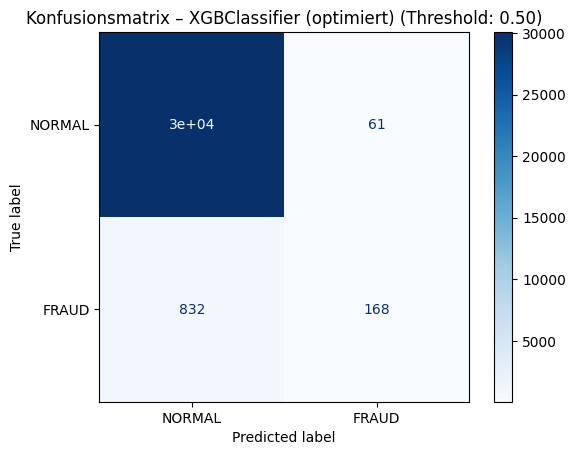

2025-06-08 21:27:48,119 - INFO - 📈 ROC-AUC: 0.8405


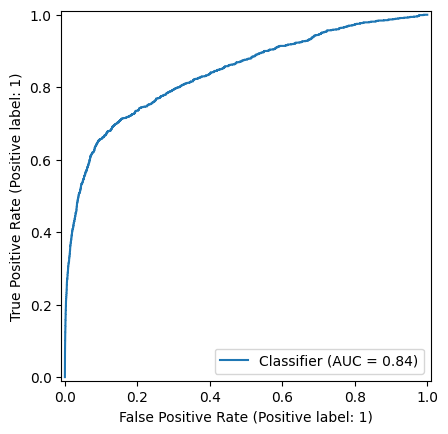

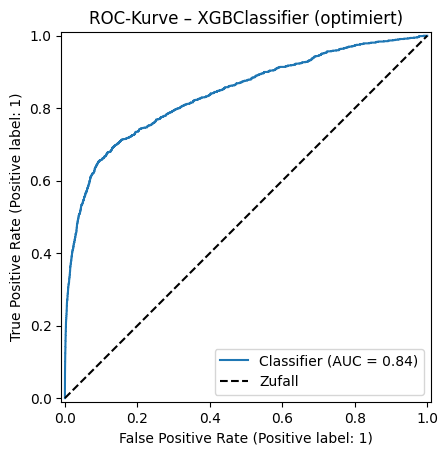

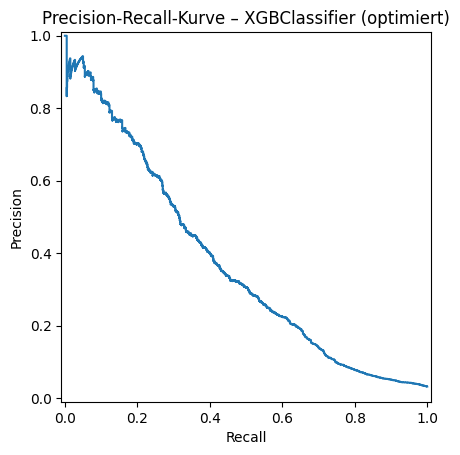

2025-06-08 21:27:48,517 - INFO - 
➡️ Iteration 1: teste Parameter {'iterations': 100, 'learning_rate': 0.1, 'depth': 6, 'verbose': 0}



🎯 Wert der Zielfunktion: -6069.01


🔍 Tune: CatBoostClassifier


2025-06-08 21:27:56,043 - INFO -   Fold 1 Score: -5095.48
2025-06-08 21:28:03,615 - INFO -   Fold 2 Score: -4775.43
2025-06-08 21:28:10,906 - INFO -   Fold 3 Score: -4805.88
2025-06-08 21:28:19,091 - INFO -   Fold 4 Score: -4643.18
2025-06-08 21:28:27,419 - INFO -   Fold 5 Score: -4917.79
2025-06-08 21:28:27,419 - INFO -   ➡️ Durchschnittlicher CV-Score: -4847.55
2025-06-08 21:28:27,419 - INFO - 
➡️ Iteration 2: teste Parameter {'iterations': 300, 'learning_rate': 0.05, 'depth': 8, 'verbose': 0}
2025-06-08 21:28:40,089 - INFO -   Fold 1 Score: -5122.78
2025-06-08 21:28:53,853 - INFO -   Fold 2 Score: -5010.84
2025-06-08 21:29:06,732 - INFO -   Fold 3 Score: -4892.93
2025-06-08 21:29:20,236 - INFO -   Fold 4 Score: -4697.98
2025-06-08 21:29:33,289 - INFO -   Fold 5 Score: -4903.52
2025-06-08 21:29:33,289 - INFO -   ➡️ Durchschnittlicher CV-Score: -4925.61
2025-06-08 21:29:33,289 - INFO - 
➡️ Iteration 3: teste Parameter {'iterations': 100, 'learning_rate': 0.1, 'depth': 4, 'verbose': 0}


📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.99     30139
       FRAUD       0.73      0.19      0.30      1000

    accuracy                           0.97     31139
   macro avg       0.85      0.59      0.64     31139
weighted avg       0.97      0.97      0.96     31139


🔲 Konfusionsmatrix:
[[30067    72]
 [  808   192]]


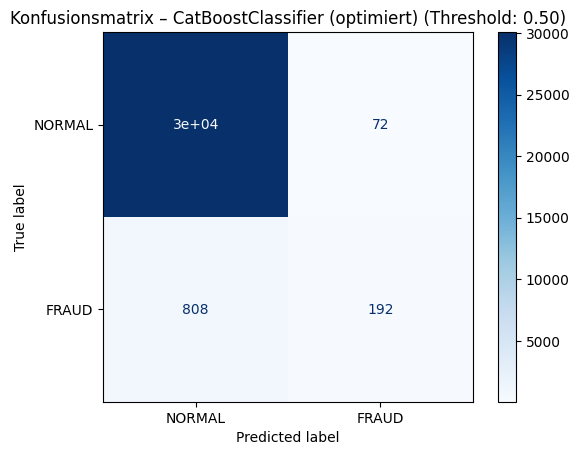

2025-06-08 21:38:09,746 - INFO - 📈 ROC-AUC: 0.8390


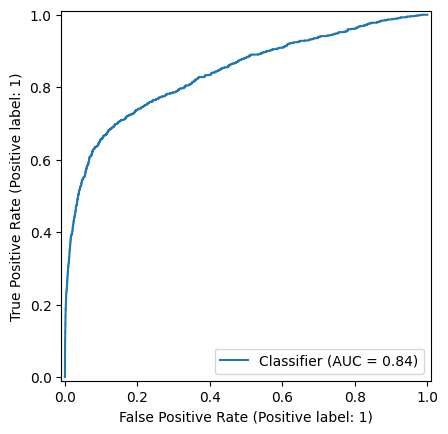

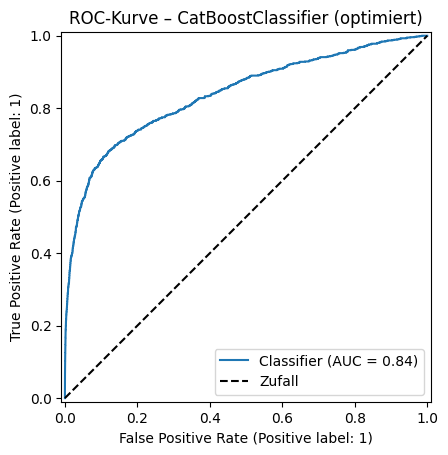

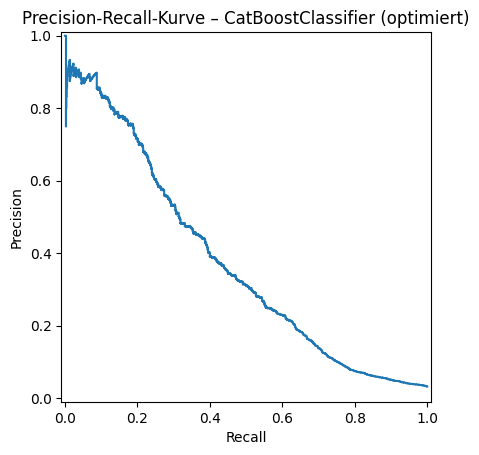

2025-06-08 21:38:10,152 - INFO - 
➡️ Iteration 1: teste Parameter {'n_estimators': 100, 'max_depth': None, 'n_jobs': 4}



🎯 Wert der Zielfunktion: -5796.96


🔍 Tune: BalancedRandomForestClassifier


2025-06-08 21:38:16,111 - INFO -   Fold 1 Score: -21585.98
2025-06-08 21:38:22,070 - INFO -   Fold 2 Score: -21485.11
2025-06-08 21:38:28,362 - INFO -   Fold 3 Score: -21347.69
2025-06-08 21:38:33,942 - INFO -   Fold 4 Score: -21831.22
2025-06-08 21:38:39,372 - INFO -   Fold 5 Score: -21287.52
2025-06-08 21:38:39,372 - INFO -   ➡️ Durchschnittlicher CV-Score: -21507.50
2025-06-08 21:38:39,379 - INFO - 
➡️ Iteration 2: teste Parameter {'n_estimators': 300, 'max_depth': 10, 'n_jobs': 4}
2025-06-08 21:38:48,347 - INFO -   Fold 1 Score: -21720.95
2025-06-08 21:38:57,068 - INFO -   Fold 2 Score: -21319.42
2025-06-08 21:39:05,437 - INFO -   Fold 3 Score: -21083.96
2025-06-08 21:39:12,655 - INFO -   Fold 4 Score: -21670.32
2025-06-08 21:39:20,418 - INFO -   Fold 5 Score: -21313.22
2025-06-08 21:39:20,418 - INFO -   ➡️ Durchschnittlicher CV-Score: -21421.57
2025-06-08 21:39:20,418 - INFO - 
➡️ Iteration 3: teste Parameter {'n_estimators': 300, 'max_depth': None, 'n_jobs': 4}
2025-06-08 21:39:2


📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.99      0.91      0.95     30139
       FRAUD       0.20      0.64      0.30      1000

    accuracy                           0.90     31139
   macro avg       0.59      0.78      0.62     31139
weighted avg       0.96      0.90      0.93     31139


🔲 Konfusionsmatrix:
[[27543  2596]
 [  363   637]]


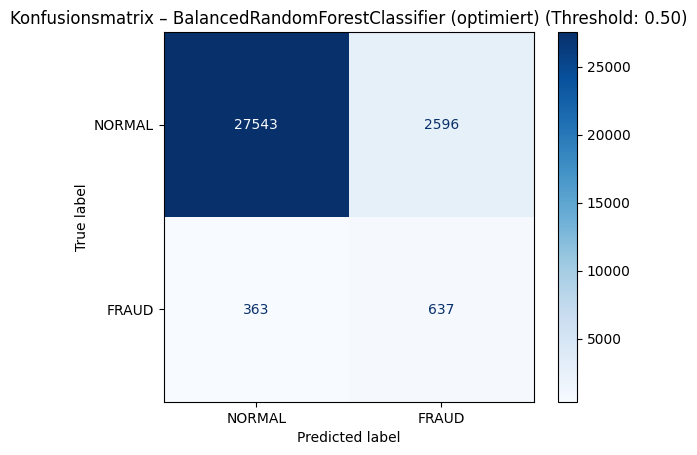

2025-06-08 21:45:53,884 - INFO - 📈 ROC-AUC: 0.8380


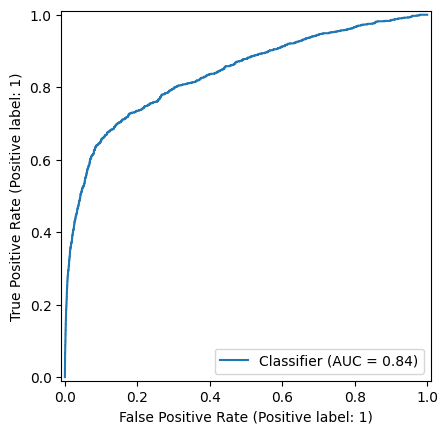

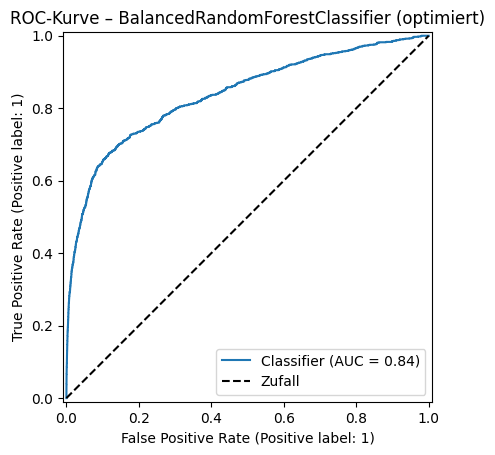

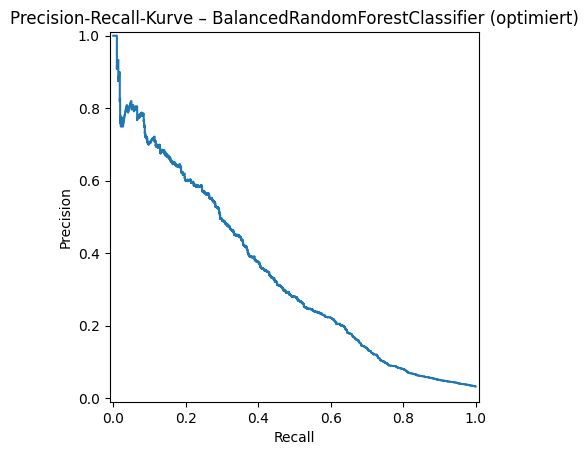

2025-06-08 21:45:54,353 - INFO - 
➡️ Iteration 1: teste Parameter {'n_estimators': 50, 'learning_rate': 0.1, 'estimator': DecisionTreeClassifier(max_depth=3), 'random_state': 42}



🎯 Wert der Zielfunktion: -25509.09


🔍 Tune: RUSBoostClassifier


2025-06-08 21:45:59,768 - INFO -   Fold 1 Score: -20067.10
2025-06-08 21:46:04,919 - INFO -   Fold 2 Score: -22242.09
2025-06-08 21:46:10,391 - INFO -   Fold 3 Score: -21896.80
2025-06-08 21:46:15,523 - INFO -   Fold 4 Score: -21979.75
2025-06-08 21:46:20,621 - INFO -   Fold 5 Score: -21255.73
2025-06-08 21:46:20,621 - INFO -   ➡️ Durchschnittlicher CV-Score: -21488.29
2025-06-08 21:46:20,621 - INFO - 
➡️ Iteration 2: teste Parameter {'n_estimators': 100, 'learning_rate': 0.05, 'estimator': DecisionTreeClassifier(max_depth=3), 'random_state': 42}
2025-06-08 21:46:26,089 - INFO -   Fold 1 Score: -19930.00
2025-06-08 21:46:31,773 - INFO -   Fold 2 Score: -20754.35
2025-06-08 21:46:37,707 - INFO -   Fold 3 Score: -20703.18
2025-06-08 21:46:43,847 - INFO -   Fold 4 Score: -21790.15
2025-06-08 21:46:49,947 - INFO -   Fold 5 Score: -20743.19
2025-06-08 21:46:49,947 - INFO -   ➡️ Durchschnittlicher CV-Score: -20784.17
2025-06-08 21:46:49,947 - INFO - 
➡️ Iteration 3: teste Parameter {'n_estim


📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.99      0.92      0.95     30139
       FRAUD       0.20      0.63      0.30      1000

    accuracy                           0.91     31139
   macro avg       0.59      0.77      0.63     31139
weighted avg       0.96      0.91      0.93     31139


🔲 Konfusionsmatrix:
[[27612  2527]
 [  373   627]]


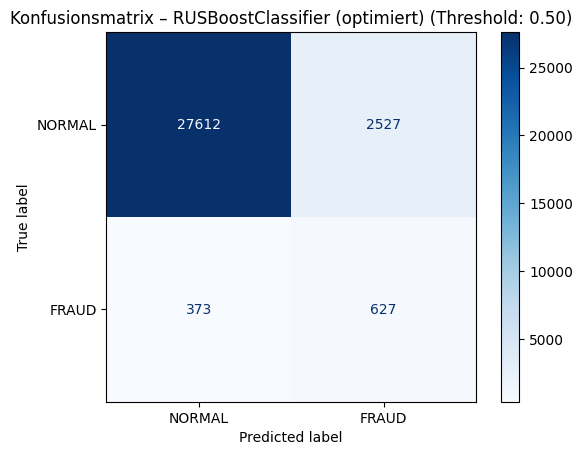

2025-06-08 21:51:11,921 - INFO - 📈 ROC-AUC: 0.8143


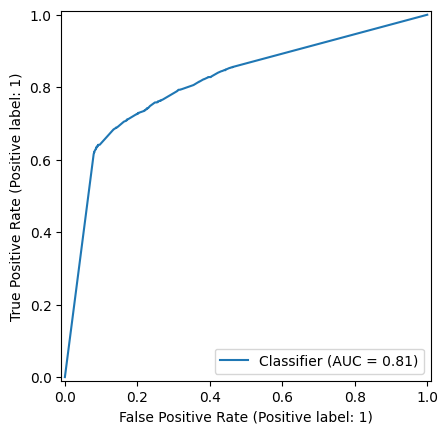

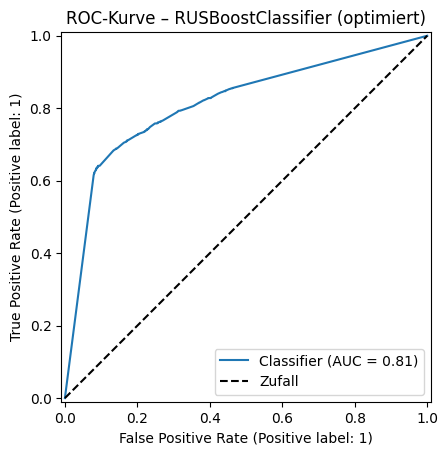

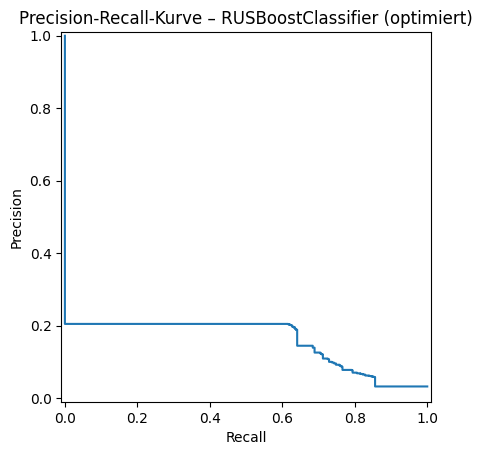

2025-06-08 21:51:12,335 - INFO - 
➡️ Iteration 1: teste Parameter {'n_estimators': 100, 'learning_rate': 0.1, 'num_leaves': 31, 'max_depth': 10, 'n_jobs': 4}



🎯 Wert der Zielfunktion: -24953.73


🔍 Tune: LGBMClassifier
[LightGBM] [Info] Number of positive: 3200, number of negative: 96442
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013341 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2195
[LightGBM] [Info] Number of data points in the train set: 99642, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032115 -> initscore=-3.405791
[LightGBM] [Info] Start training from score -3.405791


2025-06-08 21:51:18,072 - INFO -   Fold 1 Score: -5233.61


[LightGBM] [Info] Number of positive: 3200, number of negative: 96442
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012597 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2197
[LightGBM] [Info] Number of data points in the train set: 99642, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032115 -> initscore=-3.405791
[LightGBM] [Info] Start training from score -3.405791


2025-06-08 21:51:23,522 - INFO -   Fold 2 Score: -4913.75


...

[LightGBM] [Info] Number of positive: 3200, number of negative: 96443
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006274 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2195
[LightGBM] [Info] Number of data points in the train set: 99643, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032115 -> initscore=-3.405801
[LightGBM] [Info] Start training from score -3.405801


2025-06-08 21:56:27,551 - INFO -   Fold 5 Score: -5146.88
2025-06-08 21:56:27,553 - INFO -   ➡️ Durchschnittlicher CV-Score: -5062.25
2025-06-08 21:56:27,553 - INFO - 
✅ Beste Parameter gefunden!
2025-06-08 21:56:27,553 - INFO - ✅ Parameter: {'n_estimators': 100, 'learning_rate': 0.05, 'num_leaves': 50, 'max_depth': 5, 'n_jobs': 4}
2025-06-08 21:56:27,555 - INFO - ✅ CV-Score: -4901.73


[LightGBM] [Info] Number of positive: 4000, number of negative: 120553
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011703 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2203
[LightGBM] [Info] Number of data points in the train set: 124553, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032115 -> initscore=-3.405795
[LightGBM] [Info] Start training from score -3.405795
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

2025-06-08 21:56:32,578 - INFO - 🔍 Starte Evaluation für Modell: LGBMClassifier (optimiert)


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

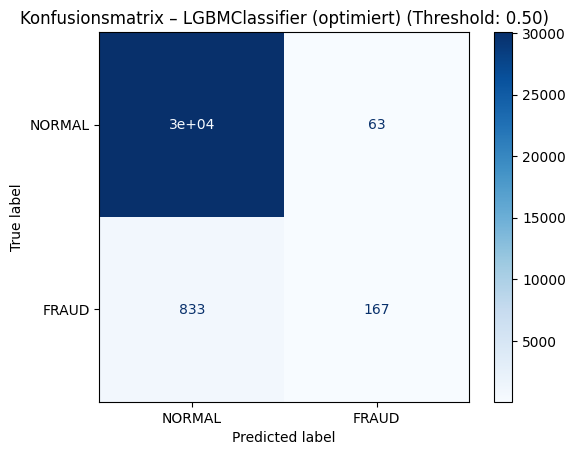

2025-06-08 21:56:39,219 - INFO - 📈 ROC-AUC: 0.8395


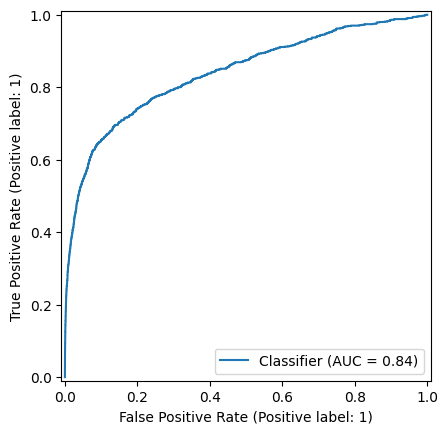

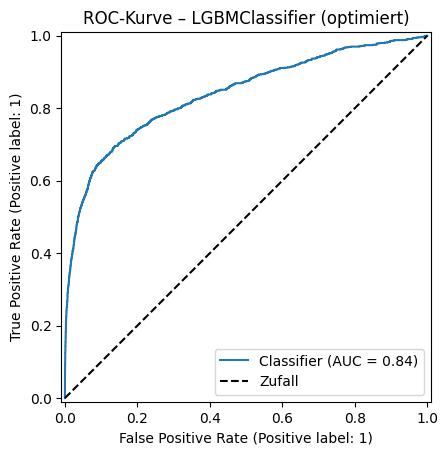

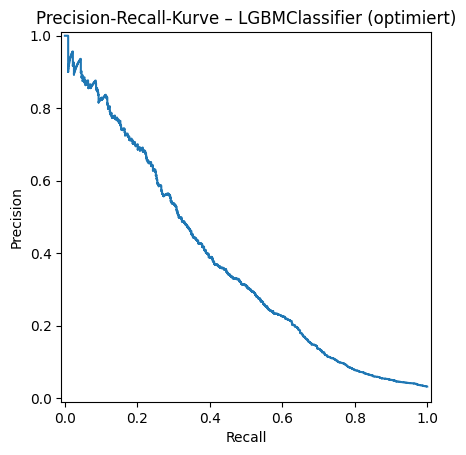


🎯 Wert der Zielfunktion: -6046.93


📊 Zusammenfassung aller Modelle:
                            Model  \
0              LogisticRegression   
1          RandomForestClassifier   
2      GradientBoostingClassifier   
3  HistGradientBoostingClassifier   
4                   XGBClassifier   
5              CatBoostClassifier   
6  BalancedRandomForestClassifier   
7              RUSBoostClassifier   
8                  LGBMClassifier   

                                         Best_Params  CV_Custom_Score  
0  {'C': 100.0, 'solver': 'liblinear', 'max_iter'...        -6110.814  
1  {'n_estimators': 500, 'max_depth': 20, 'min_sa...        -4946.990  
2  {'n_estimators': 300, 'learning_rate': 0.05, '...        -4946.516  
3  {'max_iter': 500, 'learning_rate': 0.05, 'max_...        -4960.896  
4  {'n_estimators': 300, 'learning_rate': 0.05, '...        -4912.370  
5  {'iterations': 100, 'learning_rate': 0.1, 'dep...        -4847.552  
6  {'n_estimators': 300, 'max_depth': 5, 'n_jobs'...   

In [8]:
# Speicher für alle Ergebnisse
results = []

# Master-Loop
for config in model_configs:
    print(f"\n\n==========================")
    print(f"🔍 Tune: {config['name']}")

    best_params, best_score = randomized_search_with_custom_score(
        model_class=config['model_class'],
        param_grid=config['param_grid'],
        preprocessor=preprocessor,
        X=X_train,
        y=y_train,
        damage_series=damage_train,
        n_iter=10,
        cv_splits=5,
        model_fixed_params=config['fixed_params']
    )
    
    # Merge fixed + best params
    full_params = {**best_params, **config['fixed_params']}

    # Train final model
    try:
        final_pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', config['model_class'](**full_params, random_state=42))
        ])
    except TypeError:
        # Falls random_state nicht unterstützt wird
        final_pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', config['model_class'](**full_params))
        ])

    final_pipeline.fit(X_train, y_train)

    # Evaluate on testset
    evaluate_model_with_curves(
        model=final_pipeline.named_steps['classifier'],
        model_name=config['name'] + " (optimiert)",
        preprocessor=preprocessor,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        damage_test=damage_test,
        threshold=0.5
    )

    # Ergebnis speichern
    results.append({
        'Model': config['name'],
        'Best_Params': full_params,
        'CV_Custom_Score': best_score
    })

# Zusammenfassung als DataFrame:
results_df = pd.DataFrame(results)
print("\n\n📊 Zusammenfassung aller Modelle:")
print(results_df)
